In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from BCI2000Tools.FileReader import bcistream

In [2]:
# Change this to your .dat file path
DAT_PATH = Path(r"C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R14.dat")

if not DAT_PATH.is_file():
    raise FileNotFoundError(f"File not found: {DAT_PATH}")

print(f"Using: {DAT_PATH.resolve()}")

Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R14.dat


Explore the states

In [3]:
stream = bcistream(str(DAT_PATH))

params = stream.params

JOYSTICK_STATES = {
    "x": "JoystickXpos",
    "y": "JoystickYpos",
    "button": "JoystickButtons1",
}

missing_states = [
    name
    for name in JOYSTICK_STATES.values()
    if name not in stream.statedefs
]

app_chain = params.get("ApplicationFilterChain", [])
app_modules = [row[0] for row in app_chain] if app_chain else []

print(f"File: {DAT_PATH.resolve()}")
print(
    f"Recording: {stream.nchan} channels, "
    f"{stream.samples()} samples @ {stream.samplingfreq_hz} Hz"
)
print(
    f"Application modules: "
    f"{', '.join(app_modules) if app_modules else '(none)'}"
)

print()

if not missing_states:
    print("RESULT: YES - joystick X, Y, and button data are present.")
else:
    print("RESULT: INCOMPLETE - some required joystick states are missing.")

print(f"  X state:      {JOYSTICK_STATES['x']}")
print(f"  Y state:      {JOYSTICK_STATES['y']}")
print(f"  Button state: {JOYSTICK_STATES['button']}")

if missing_states:
    print(f"\nMissing states: {', '.join(missing_states)}")

File: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R14.dat
Recording: 16 channels, 18784 samples @ 256.0 Hz
Application modules: USBHIDJoystickTask, KeystrokeFilter, ParallelPortFilter

RESULT: YES - joystick X, Y, and button data are present.
  X state:      JoystickXpos
  Y state:      JoystickYpos
  Button state: JoystickButtons1


In [4]:
wanted = [
    "JoystickXpos",
    "JoystickYpos",
    "JoystickButtons1",
]

sig, states = stream.decode(
    nsamp="all",
    states=wanted
)

sig = np.asarray(sig)

rows = []

for name in wanted:
    a = np.asarray(states[name]).ravel()

    rows.append({
        "state": name,
        "min": a.min(),
        "max": a.max(),
        "mean": a.mean(),
        "n_unique": np.unique(a).size,
        "n_changes": int(np.count_nonzero(np.diff(a))),
        "n_samples": a.size,
    })

summary_df = pd.DataFrame(rows).set_index("state")

summary_df

,min,max,mean,n_unique,n_changes,n_samples
state,,,,,,
JoystickXpos,0,24094,16102.693675,335,1661,18784
JoystickYpos,0,29651,16740.743186,434,2244,18784
JoystickButtons1,0,0,0.000000,1,0,18784


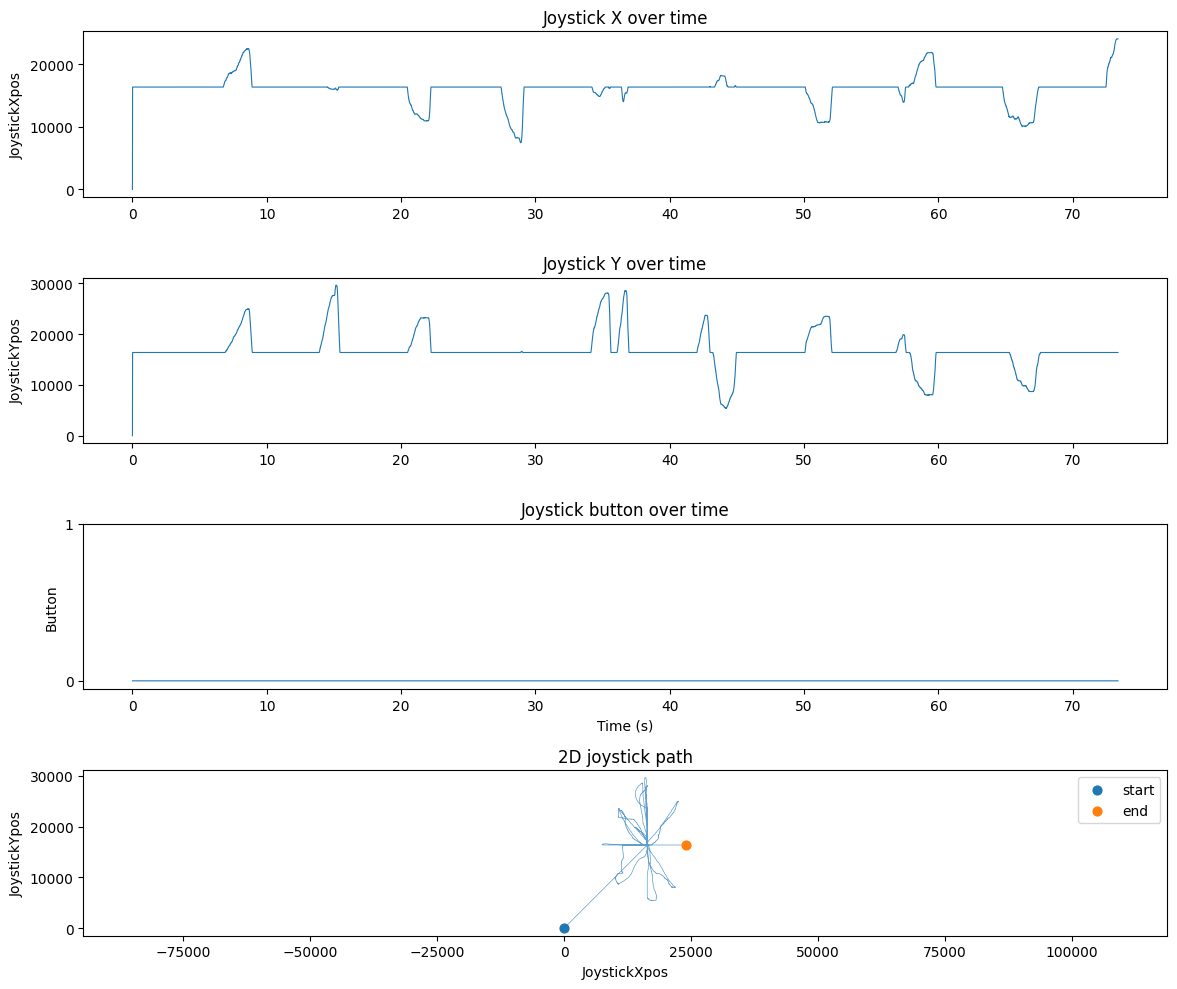

JoystickXpos: min=0, max=24094, unique=335
JoystickYpos: min=0, max=29651, unique=434
JoystickButtons1: min=0, max=0, changes=0


In [5]:
jx = np.asarray(states["JoystickXpos"]).ravel()
jy = np.asarray(states["JoystickYpos"]).ravel()
button = np.asarray(states["JoystickButtons1"]).ravel()

t = np.arange(jx.size) / stream.samplingfreq_hz

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(t, jx, lw=0.8)
axes[0].set_ylabel("JoystickXpos")
axes[0].set_title("Joystick X over time")

axes[1].plot(t, jy, lw=0.8)
axes[1].set_ylabel("JoystickYpos")
axes[1].set_title("Joystick Y over time")

axes[2].plot(t, button, lw=0.8)
axes[2].set_ylabel("Button")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Joystick button over time")
axes[2].set_yticks([0, 1])

axes[3].plot(jx, jy, lw=0.5, alpha=0.7)
axes[3].scatter(jx[0], jy[0], s=40, zorder=3, label="start")
axes[3].scatter(jx[-1], jy[-1], s=40, zorder=3, label="end")
axes[3].set_xlabel("JoystickXpos")
axes[3].set_ylabel("JoystickYpos")
axes[3].set_title("2D joystick path")
axes[3].legend()
axes[3].set_aspect("equal", adjustable="datalim")

fig.tight_layout()
plt.show()

print(
    f"JoystickXpos: min={jx.min()}, max={jx.max()}, "
    f"unique={np.unique(jx).size}"
)

print(
    f"JoystickYpos: min={jy.min()}, max={jy.max()}, "
    f"unique={np.unique(jy).size}"
)

print(
    f"JoystickButtons1: min={button.min()}, max={button.max()}, "
    f"changes={np.count_nonzero(np.diff(button))}"
)

In [6]:
channel_names = list(params.get("ChannelNames") or [])

if len(channel_names) != sig.shape[0]:
    channel_names = [
        f"Channel{i + 1}"
        for i in range(sig.shape[0])
    ]

rows = []

for i, name in enumerate(channel_names):
    channel = np.asarray(sig[i]).ravel()

    rows.append({
        "channel": name,
        "min": float(channel.min()),
        "max": float(channel.max()),
        "mean": float(channel.mean()),
        "std": float(channel.std()),
        "n_samples": channel.size,
    })

channel_df = pd.DataFrame(rows).set_index("channel")

channel_df

,min,max,mean,std,n_samples
channel,,,,,
Channel1,-114.900002,114.900002,0.032698,71.136665,18784
Channel2,-114.900002,114.800003,0.042116,71.241104,18784
Channel3,-114.900002,114.599998,0.077561,71.213943,18784
Channel4,-114.800003,114.800003,0.016487,71.177269,18784
Channel5,-114.800003,114.800003,-0.086286,71.250267,18784
Channel6,-114.900002,114.500000,0.045267,71.153336,18784
Channel7,-114.700005,114.800003,0.105462,71.290207,18784
Channel8,-114.900002,114.800003,0.105515,71.230179,18784
Channel9,-114.900002,114.800003,0.026102,71.196686,18784


# **exploring joystick activity around trials**

Found 10 trial starts.


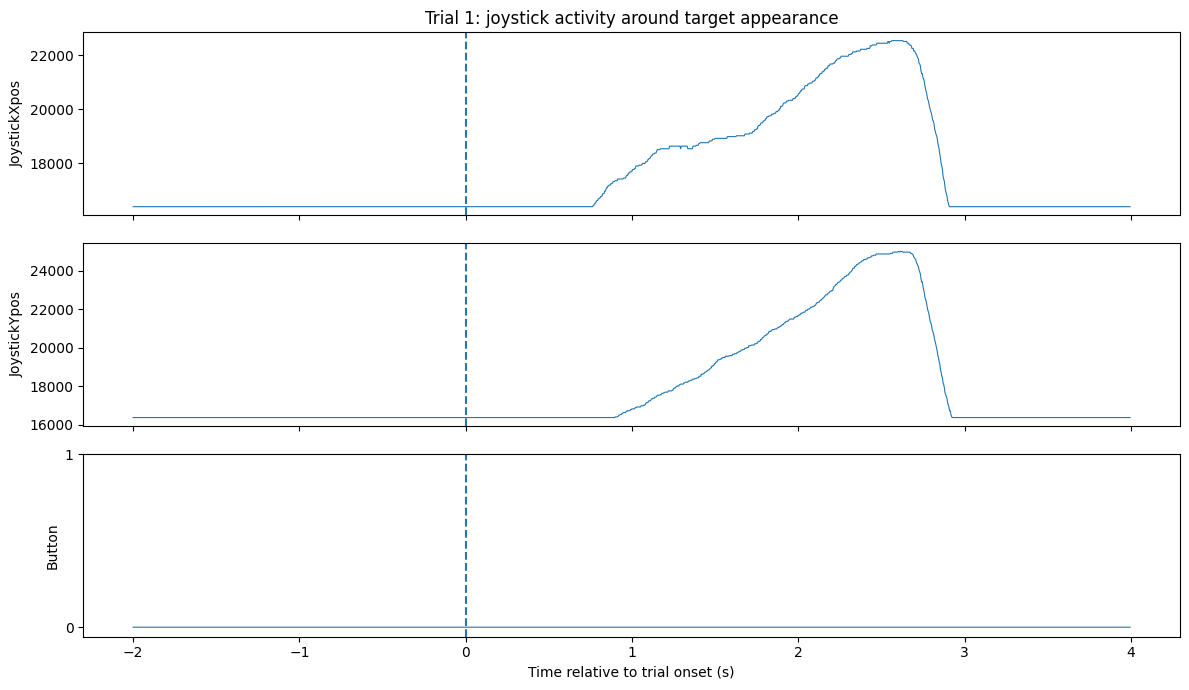

Trial 1: onset at 6.000 s


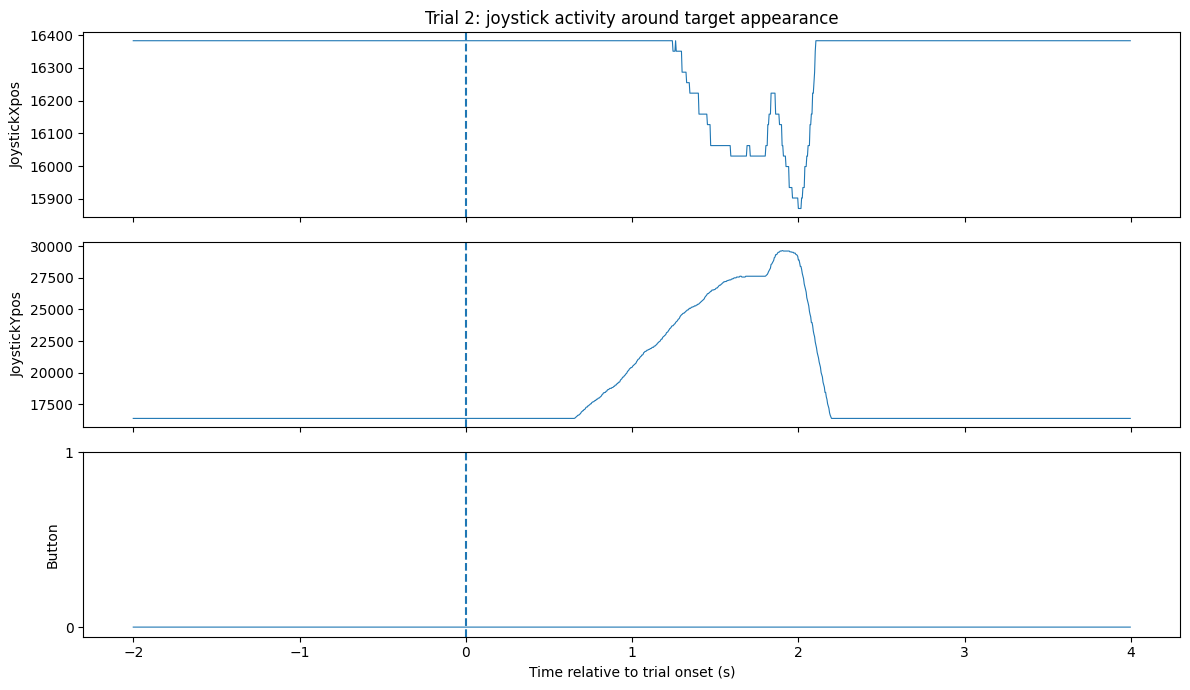

Trial 2: onset at 13.250 s


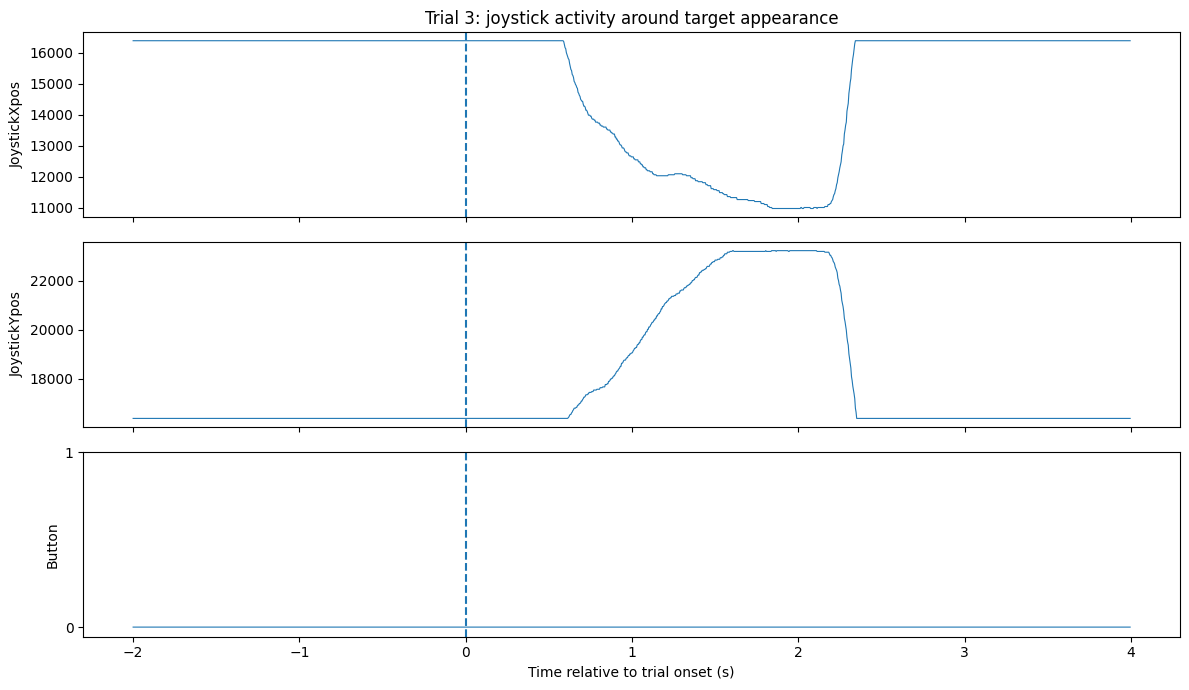

Trial 3: onset at 19.875 s


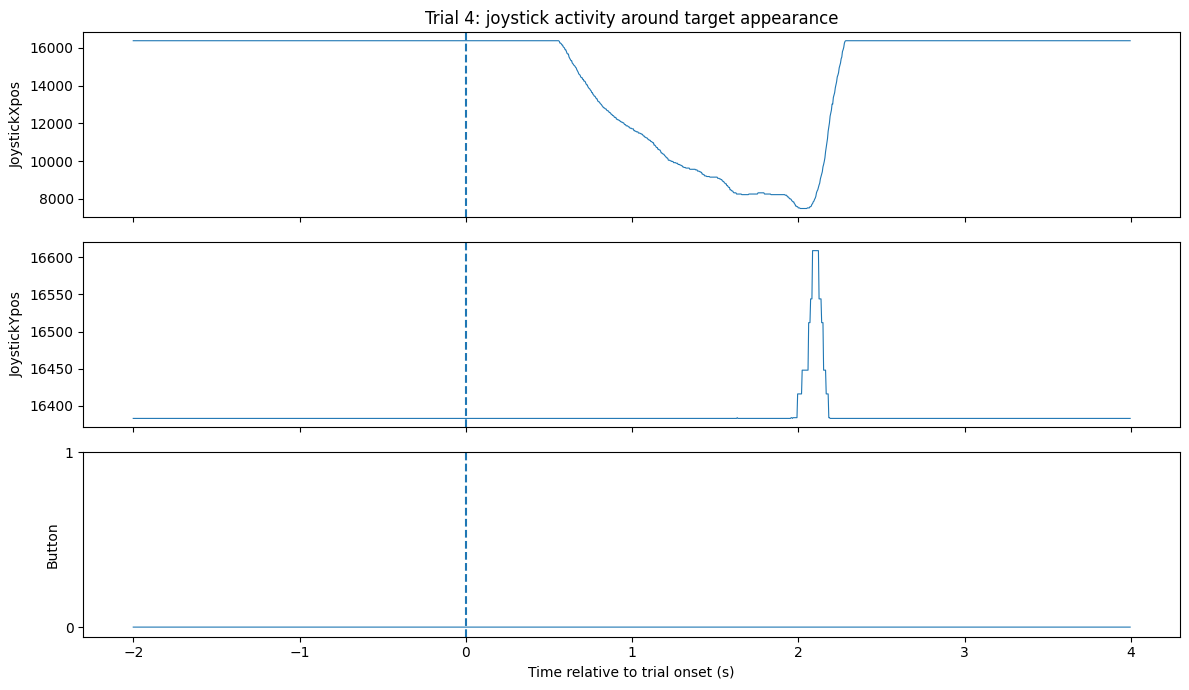

Trial 4: onset at 26.875 s


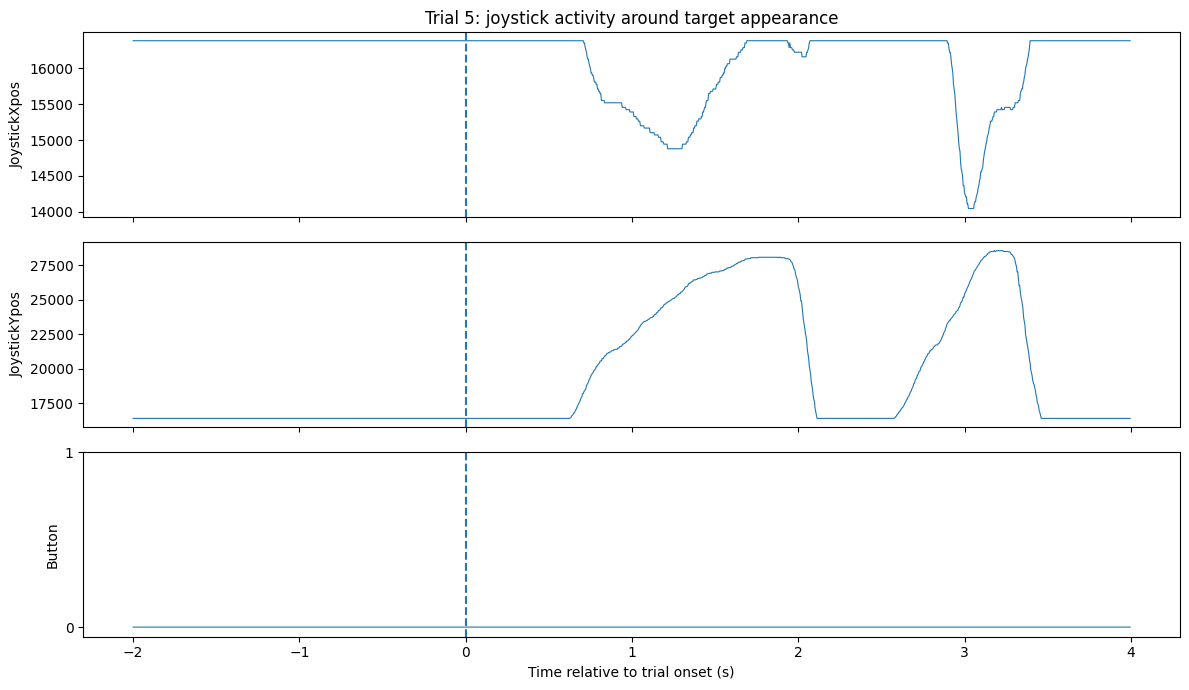

Trial 5: onset at 33.500 s


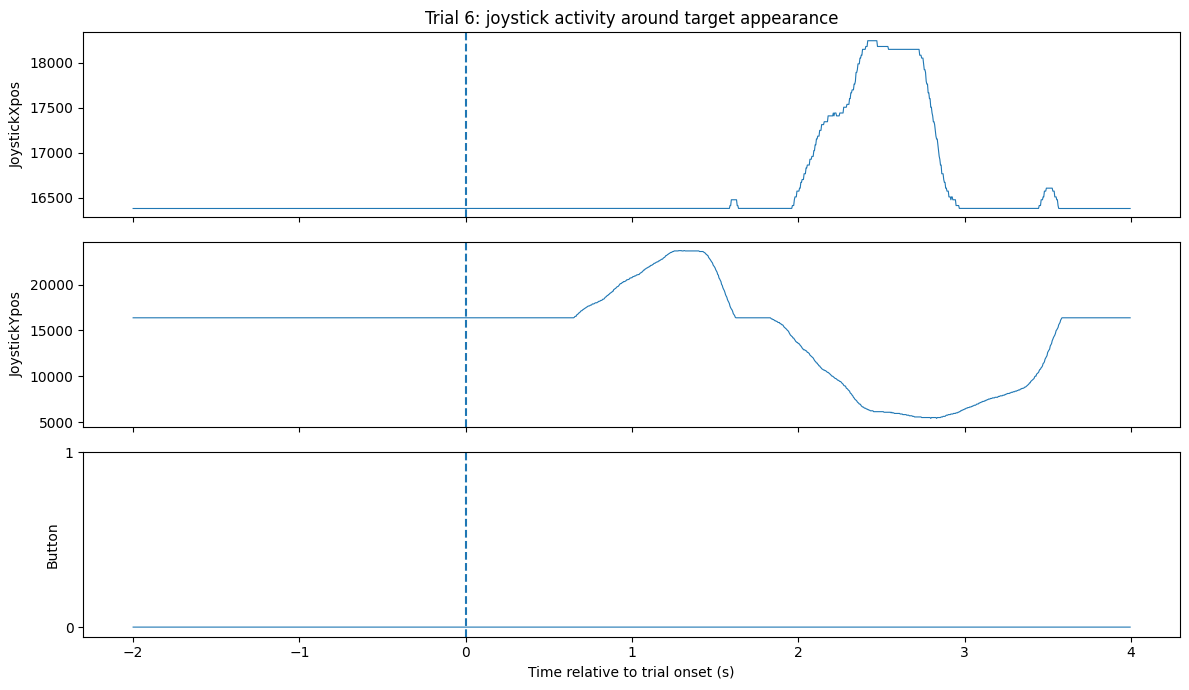

Trial 6: onset at 41.375 s


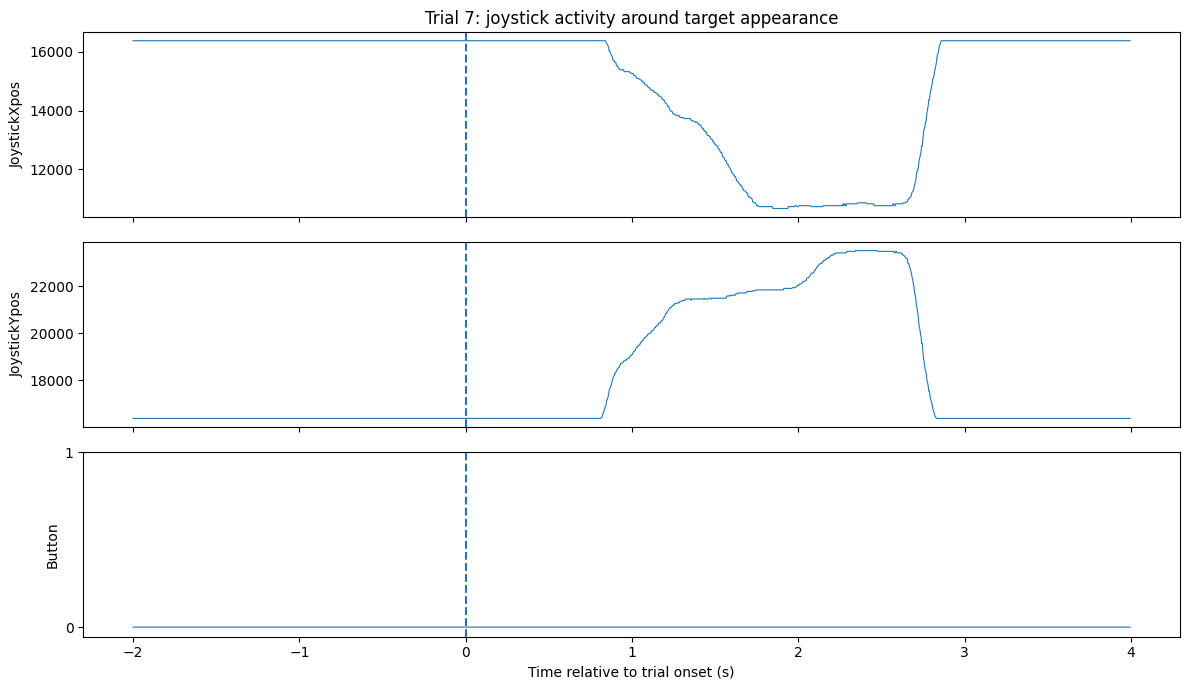

Trial 7: onset at 49.250 s


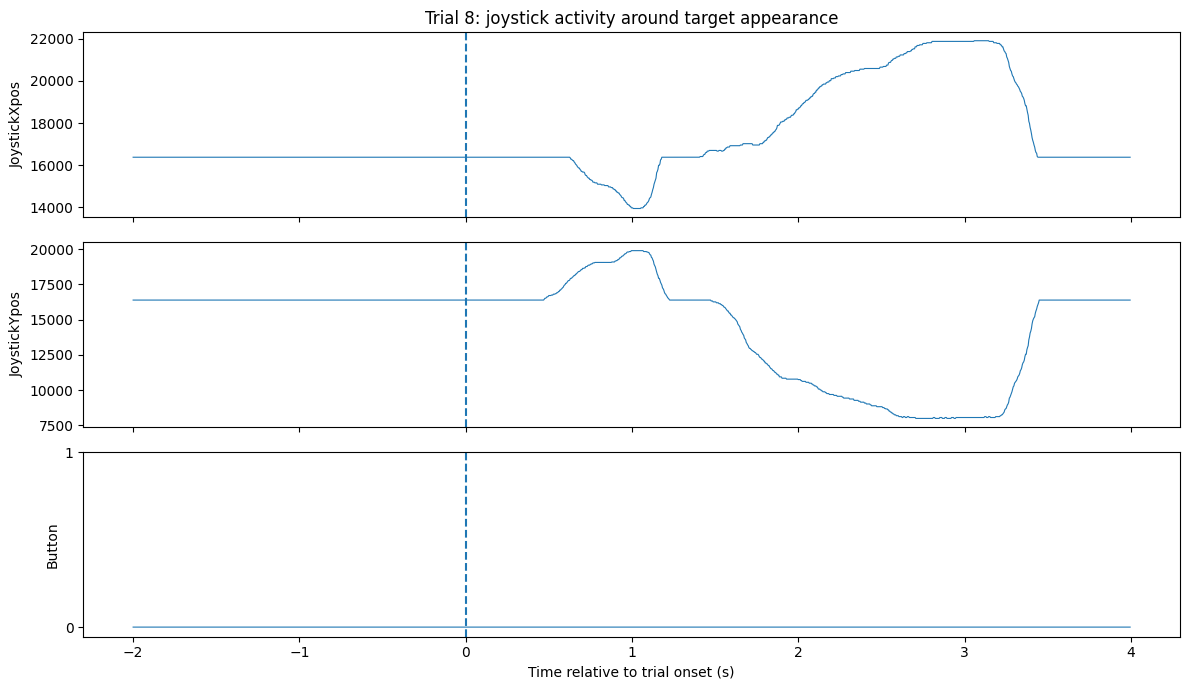

Trial 8: onset at 56.375 s


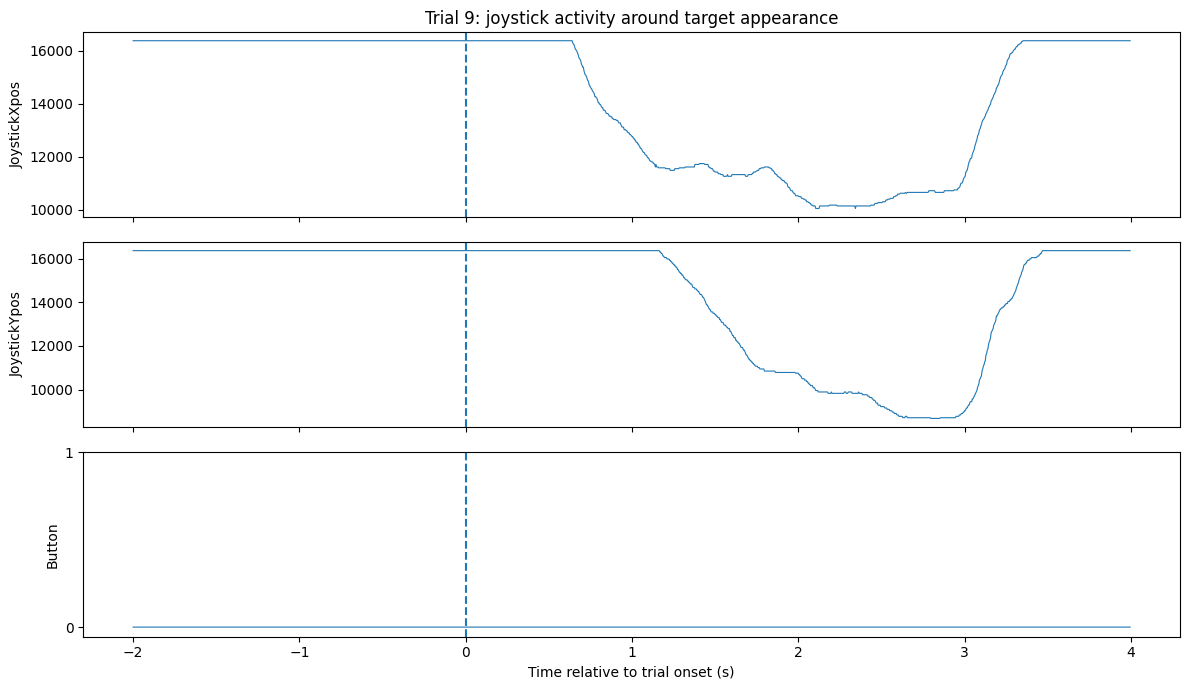

Trial 9: onset at 64.125 s


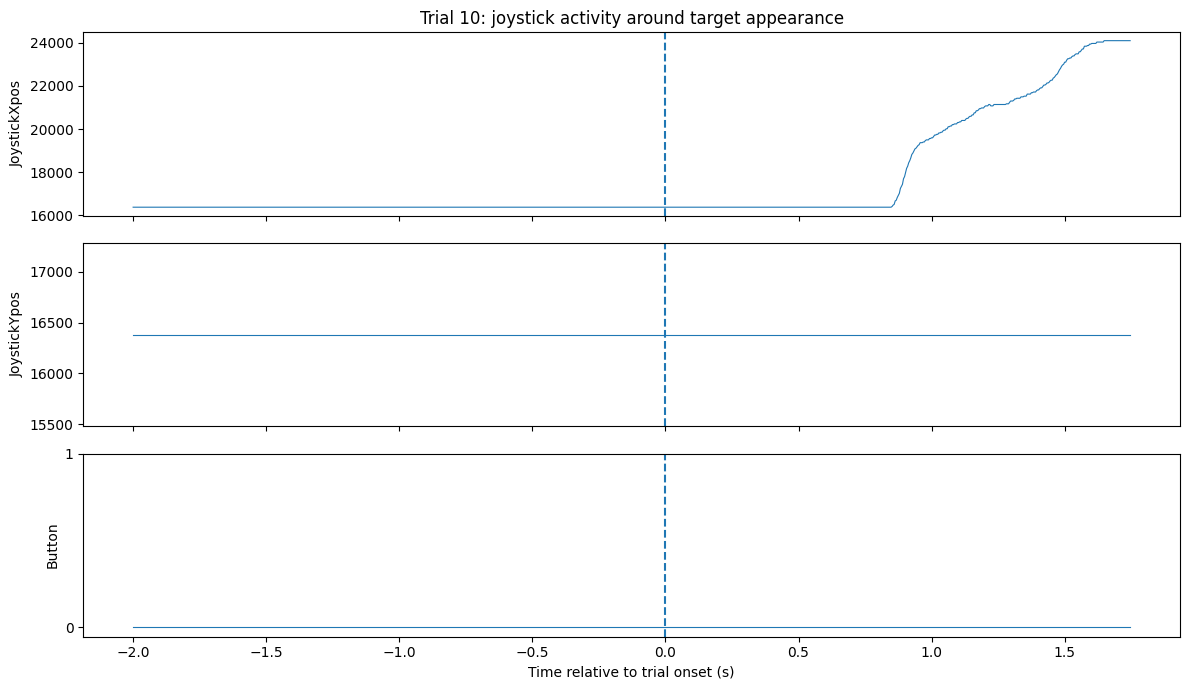

Trial 10: onset at 71.625 s


In [7]:
# Look at joystick activity around each trial onset.
# Trial onset = transition into TaskPhase 4 (TargetVisible).

TRIAL_START_PHASE = 4
WINDOW_BEFORE = 2.0   # seconds
WINDOW_AFTER = 4.0    # seconds

wanted = [
    "JoystickXpos",
    "JoystickYpos",
    "JoystickButtons1",
    "TaskPhase",
    "TaskTrial",
]

missing = [
    name for name in wanted
    if name not in stream.statedefs
]

if missing:
    print(f"Cannot analyze trial starts. Missing states: {', '.join(missing)}")

else:
    _, trial_states = stream.decode(
        nsamp="all",
        states=wanted
    )

    jx = np.asarray(trial_states["JoystickXpos"]).ravel()
    jy = np.asarray(trial_states["JoystickYpos"]).ravel()
    button = np.asarray(trial_states["JoystickButtons1"]).ravel()
    phase = np.asarray(trial_states["TaskPhase"]).ravel()
    trial = np.asarray(trial_states["TaskTrial"]).ravel()

    fs = stream.samplingfreq_hz

    # Find samples where TaskPhase changes INTO TargetVisible.
    trial_start_samples = np.where(
        (phase[1:] == TRIAL_START_PHASE) &
        (phase[:-1] != TRIAL_START_PHASE)
    )[0] + 1

    print(f"Found {len(trial_start_samples)} trial starts.")

    for start_sample in trial_start_samples:
        trial_number = int(trial[start_sample])

        before_samples = int(WINDOW_BEFORE * fs)
        after_samples = int(WINDOW_AFTER * fs)

        start = max(0, start_sample - before_samples)
        stop = min(jx.size, start_sample + after_samples)

        # Time relative to trial onset.
        t_relative = (
            np.arange(start, stop) - start_sample
        ) / fs

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 7),
            sharex=True
        )

        axes[0].plot(t_relative, jx[start:stop], lw=0.8)
        axes[0].axvline(0, linestyle="--")
        axes[0].set_ylabel("JoystickXpos")
        axes[0].set_title(
            f"Trial {trial_number}: joystick activity around target appearance"
        )

        axes[1].plot(t_relative, jy[start:stop], lw=0.8)
        axes[1].axvline(0, linestyle="--")
        axes[1].set_ylabel("JoystickYpos")

        axes[2].plot(t_relative, button[start:stop], lw=0.8)
        axes[2].axvline(0, linestyle="--")
        axes[2].set_ylabel("Button")
        axes[2].set_xlabel("Time relative to trial onset (s)")
        axes[2].set_yticks([0, 1])

        fig.tight_layout()
        plt.show()

        print(
            f"Trial {trial_number}: "
            f"onset at {start_sample / fs:.3f} s"
        )